Plot population pyramid for Malaysia for an ethnicity from state data

In [35]:
import pandas as pd

population_data = pd.read_csv("population_state.csv")
population_data.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [36]:
population_data["year"] = pd.to_datetime(population_data["date"]).dt.year
population_data.head()

,state,date,sex,age,ethnicity,population,year
0,Johor,1970-01-01,both,overall,overall,1325.6,1970
1,Johor,1970-01-01,both,0-4,overall,210.1,1970
2,Johor,1970-01-01,both,5-9,overall,215.7,1970
3,Johor,1970-01-01,both,10-14,overall,192.2,1970
4,Johor,1970-01-01,both,15-19,overall,152.8,1970


Map ethnicity for consistency

In [37]:
ETHNICITY_MAP = {
    'bumi' : 'Bumiputera',
    'bumi_malay': 'Bumiputera',
    'bumi_other': 'Bumiputera',
    'chinese': 'Chinese',
    'indian': 'Indian',
    'other': 'Other',
    'other_citizen': 'Other',
    'other_noncitizen': 'Other'
}

population_data["ethnicity_group"] = population_data["ethnicity"].map(ETHNICITY_MAP)
population_data.head()

,state,date,sex,age,ethnicity,population,year,ethnicity_group
0,Johor,1970-01-01,both,overall,overall,1325.6,1970,NaN
1,Johor,1970-01-01,both,0-4,overall,210.1,1970,NaN
2,Johor,1970-01-01,both,5-9,overall,215.7,1970,NaN
3,Johor,1970-01-01,both,10-14,overall,192.2,1970,NaN
4,Johor,1970-01-01,both,15-19,overall,152.8,1970,NaN


Filter for 2005 Bumiputera

In [38]:
population_data_filtered = population_data[(population_data["ethnicity_group"] == "Bumiputera") &
                                 (population_data["year"] == 2005) &
                                 (population_data["age"] != "overall") &
                                 (population_data["sex"] != "both")].copy()
population_data_filtered.head()

,state,date,sex,age,ethnicity,population,year,ethnicity_group
9177,Johor,2005-01-01,female,0-4,bumi_malay,86.6,2005,Bumiputera
9178,Johor,2005-01-01,female,0-4,bumi_other,2.7,2005,Bumiputera
9184,Johor,2005-01-01,female,5-9,bumi_malay,90.3,2005,Bumiputera
9185,Johor,2005-01-01,female,5-9,bumi_other,1.6,2005,Bumiputera
9191,Johor,2005-01-01,female,10-14,bumi_malay,84.7,2005,Bumiputera


In [39]:
population_data_filtered = population_data_filtered.drop(["ethnicity", "date"], axis = 1)
population_data_filtered.head()

,state,sex,age,population,year,ethnicity_group
9177,Johor,female,0-4,86.6,2005,Bumiputera
9178,Johor,female,0-4,2.7,2005,Bumiputera
9184,Johor,female,5-9,90.3,2005,Bumiputera
9185,Johor,female,5-9,1.6,2005,Bumiputera
9191,Johor,female,10-14,84.7,2005,Bumiputera


Group by age group and sex

In [40]:
population_data_pyramid = population_data_filtered.groupby(["age", "sex"], as_index = False)['population'].sum()
population_data_pyramid

,age,sex,population
0,0-4,female,838.2
1,0-4,male,884.4
2,10-14,female,865.9
3,10-14,male,902.3
4,15-19,female,817.5
5,15-19,male,834.8
6,20-24,female,737.5
7,20-24,male,751.9
8,25-29,female,578.4
9,25-29,male,587.5


Extract digits from age groups, then sort by age groups integer values

In [41]:
population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
population_data_pyramid = population_data_pyramid.sort_values("age_order")
population_data_pyramid

,age,sex,population,age_order
0,0-4,female,838.2,0
1,0-4,male,884.4,0
18,5-9,female,876.7,5
19,5-9,male,923.8,5
2,10-14,female,865.9,10
3,10-14,male,902.3,10
4,15-19,female,817.5,15
5,15-19,male,834.8,15
6,20-24,female,737.5,20
7,20-24,male,751.9,20


As string ordering is based on Unicode character order, reindex using age order

In [42]:
age_order = population_data_pyramid["age"].unique()
population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
population_data_pyramid_table

sex,female,male
age,,
0-4,838.2,884.4
5-9,876.7,923.8
10-14,865.9,902.3
15-19,817.5,834.8
20-24,737.5,751.9
25-29,578.4,587.5
30-34,518.8,514.8
35-39,496.2,488.1
40-44,446.3,453.2


Negate male values to plot male data on left hand side of population pyramid

In [43]:
population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
population_data_pyramid_table

sex,female,male
age,,
0-4,838.2,-884.4
5-9,876.7,-923.8
10-14,865.9,-902.3
15-19,817.5,-834.8
20-24,737.5,-751.9
25-29,578.4,-587.5
30-34,518.8,-514.8
35-39,496.2,-488.1
40-44,446.3,-453.2


Plot population pyramid

C:\Users\Acer\AppData\Local\Temp\ipykernel_2880\3217514777.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


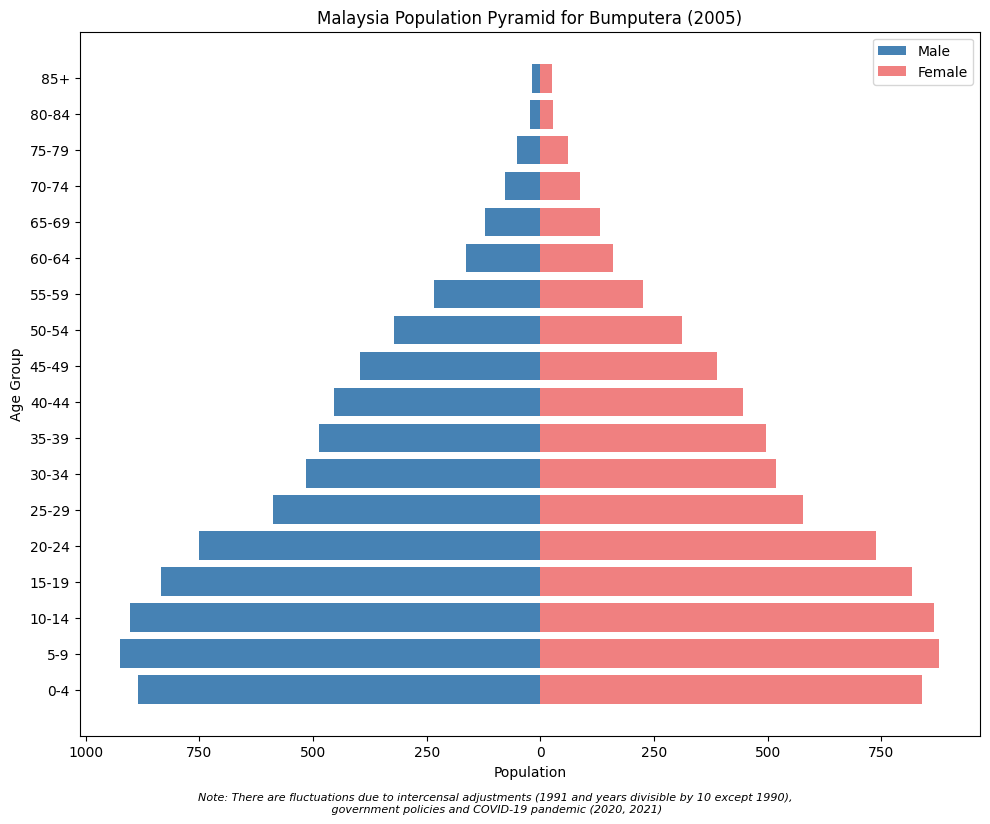

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

ax.set_title("Malaysia Population Pyramid for Bumputera (2005)")
ax.set_xlabel("Population")
ax.set_ylabel("Age Group")

# Make x-axis labels positive
xticks = ax.get_xticks()
ax.set_xticklabels([abs(int(x)) for x in xticks])

ax.legend()
plt.tight_layout()
plt.figtext(
        0.5, -0.02, 
        "Note: There are fluctuations due to intercensal adjustments (1991 and years divisible by 10 except 1990),\n government policies and COVID-19 pandemic (2020, 2021)",
        wrap=True, ha='center', fontsize=8, style='italic'
    )
plt.show()

Plot for years after 1979 and remapped ethnicity groups

C:\Users\Acer\AppData\Local\Temp\ipykernel_2880\1024171782.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([abs(int(x)) for x in xticks])


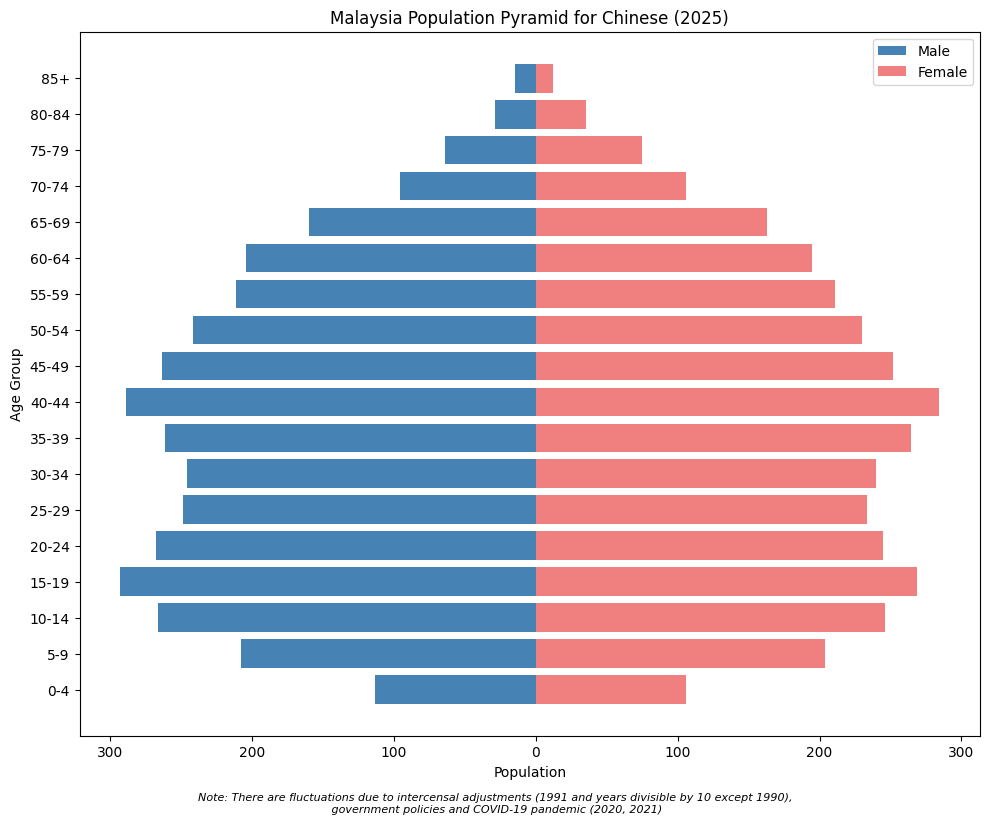

In [45]:
ETHNICITY_MAP = {
    'bumi' : 'Bumiputera',
    'bumi_malay': 'Bumiputera',
    'bumi_other': 'Bumiputera',
    'chinese': 'Chinese',
    'indian': 'Indian',
    'other': 'Other',
    'other_citizen': 'Other',
    'other_noncitizen': 'Other'
}

def data_pyramid_malaysia_by_year_and_ethnicity(year, ethnicity):
    population_data["year"] = pd.to_datetime(population_data["date"]).dt.year
    population_data["ethnicity_group"] = population_data["ethnicity"].map(ETHNICITY_MAP)

    population_data_filtered = population_data[(population_data["ethnicity_group"] == ethnicity) &
                                 (population_data["year"] == year) &
                                 (population_data["age"] != "overall") &
                                 (population_data["sex"] != "both")].copy()
    population_data_filtered = population_data_filtered.drop(["ethnicity", "date"], axis = 1)

    population_data_pyramid = population_data_filtered.groupby(["age", "sex"], as_index = False)['population'].sum()

    population_data_pyramid["age_order"] = population_data_pyramid["age"].str.extract(r"(\d+)").astype(int)
    population_data_pyramid = population_data_pyramid.sort_values("age_order")

    age_order = population_data_pyramid["age"].unique()
    population_data_pyramid_table = population_data_pyramid.pivot_table(
                                    index = "age", columns="sex", values="population").fillna(0)
    population_data_pyramid_table = population_data_pyramid_table.reindex(age_order)
    
    return population_data_pyramid_table

def plot_malaysia_population_pyramid_year(year, ethnicity):
    population_data_pyramid_table = data_pyramid_malaysia_by_year_and_ethnicity(year, ethnicity)
    population_data_pyramid_table["male"] = -population_data_pyramid_table["male"]
    
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["male"], color="steelblue", label="Male")
    ax.barh(population_data_pyramid_table.index, population_data_pyramid_table["female"], color="lightcoral", label="Female")

    ax.set_title(f"Malaysia Population Pyramid for {ethnicity} ({year})")
    ax.set_xlabel("Population")
    ax.set_ylabel("Age Group")

    xticks = ax.get_xticks()
    ax.set_xticklabels([abs(int(x)) for x in xticks])

    ax.legend()
    plt.tight_layout()
    plt.figtext(
        0.5, -0.02, 
        "Note: There are fluctuations due to intercensal adjustments (1991 and years divisible by 10 except 1990),\n government policies and COVID-19 pandemic (2020, 2021)",
        wrap=True, ha='center', fontsize=8, style='italic'
    )
    plt.show()

plot_malaysia_population_pyramid_year(2025, "Chinese")